<a href="https://colab.research.google.com/github/rich7420/CNN-Assignment-2025/blob/main/CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# CNN Classroom Exercise: Image Classification with CIFAR-10
# Objective: Practice building, training, and evaluating a CNN using TensorFlow/Keras
# Environment: Google Colab with GPU
# Dataset: CIFAR-10 (10 classes of 32x32 color images)

# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Step 2: Load and Preprocess CIFAR-10 Dataset
# CIFAR-10 contains 60,000 32x32 color images in 10 classes (e.g., airplane, cat, dog)
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to range [0, 1]
train_images, test_images = train_images / 255.0, test_images / 255.0

# Define class names for visualization
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

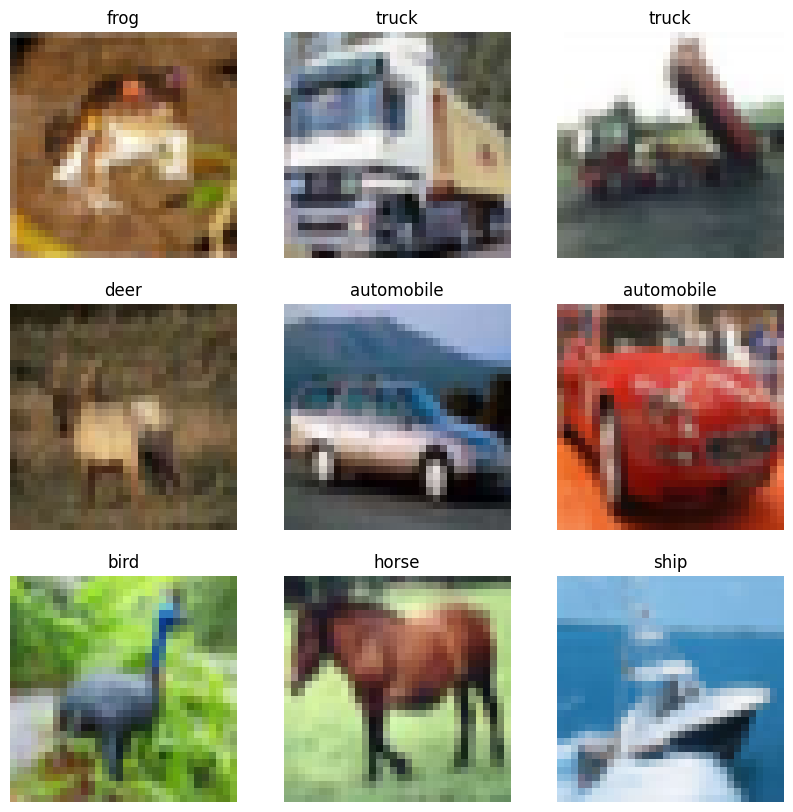

In [4]:
# Step 3: Visualize Sample Data
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')
plt.show()

In [5]:
# Task 3: Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=7.5,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
train_generator = train_datagen.flow(train_images, train_labels, batch_size=64)

In [ ]:
#Task 1: Model Architecture Enhancement

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import sys
import io
import pandas as pd
from tensorflow.keras.callbacks import CSVLogger

# 根據最佳超參數組合建立模型
model = models.Sequential()

# 第一層卷積：64 filters, 3x3 kernel (改為較小的kernel)
model.add(layers.Conv2D(64, (3, 3), padding='same', input_shape=(32, 32, 3)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2))  # dropout1 = 0.2

# 第二層卷積：64 filters, 3x3 kernel
model.add(layers.Conv2D(64, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.1))  # dropout1 = 0.1

# 第三層卷積：128 filters
model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.3))  # dropout2 = 0.3

# 第四層卷積：128 filters
model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.3))  # dropout2 = 0.3

# 第五層卷積：新增
model.add(layers.Conv2D(128, (3, 3), padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.3))

# 平坦化並輸出至全連接層
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))  # 新增 Dense 層
model.add(layers.Dropout(0.3))
model.add(layers.Dense(64, activation='relu'))  # 原 Dense 層
model.add(layers.Dropout(0.3))  # dropout_dense = 0.3
model.add(layers.Dense(10, activation='softmax'))

# Task 2: Hyperparameter Optimization

#編譯模型
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # best lr
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 顯示模型架構
model.summary()

# 設定回呼函數（新增 CSVLogger）
csv_logger = CSVLogger('training_log.csv', append=False)


# 設定回呼函數：EarlyStopping + ReduceLROnPlateau
callbacks_list = [
    # 提早偵測收斂，避免後期波動干擾最佳模型
    EarlyStopping(
        monitor='val_loss',
        patience=9,  # 從 7 改為 6，略微提早觸發
        restore_best_weights=True
    ),

    # 學習率調整變得更「溫和」且減少干擾
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,       # 原本 0.6，改為標準 0.5，讓下降更有力
        patience=4,       # 從 3 增加為 4，避免太頻繁調整
        min_lr=1e-5,      # 設定最低學習率，避免後期太小無法學習
        verbose=1
    ),
    
    #保留最佳模型
    ModelCheckpoint(  
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,  # 如果只想存 weights 改為 True
        verbose=1
    ),

    # 記錄 log（保留）
    csv_logger
]
# 記錄所有訓練歷程（可多次訓練後合併）
histories = []

# 訓練模型
temp_history = model.fit(
    train_generator,
    epochs= 50,
    validation_data=(test_images, test_labels),
    callbacks=callbacks_list
)

histories.append(temp_history)

c:\Users\et611\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 680,970 (2.60 MB)

 Trainable params: 679,946 (2.59 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 98ms/step - accuracy: 0.2482 - loss: 2.0119 - val_accuracy: 0.3562 - val_loss: 1.8379 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.4380 - loss: 1.5306 - val_accuracy: 0.3898 - val_loss: 1.7476 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.5240 - loss: 1.3368 - val_accuracy: 0.4075 - val_loss: 1.8025 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.5714 - loss: 1.2158 - val_accuracy: 0.6224 - val_loss: 1.0672 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6113 - loss: 1.1195 - val_accuracy: 0.6684 - val_loss: 0.9402 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.6390 - loss: 1.0465 - val_accuracy: 0.5631 - val_loss: 1.3987 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6566 - l

In [8]:
# Step 7: Evaluate the Model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")


313/313 - 2s - 6ms/step - accuracy: 0.8114 - loss: 0.5520

Test accuracy: 0.8114


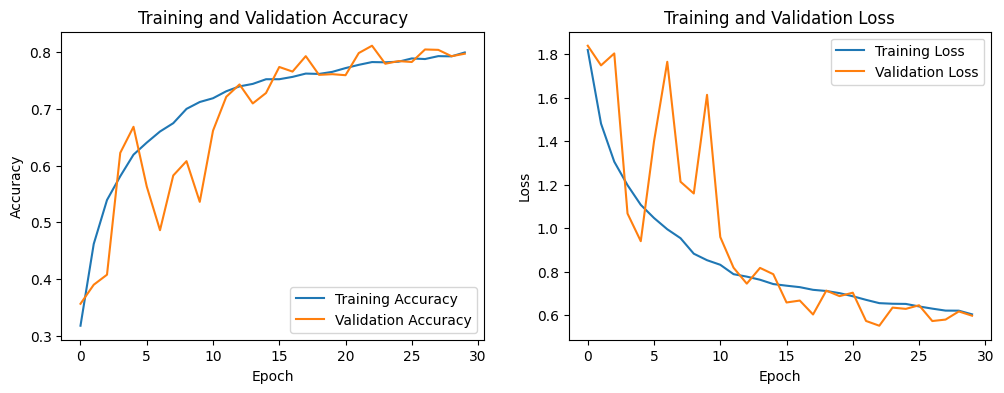

In [9]:
#Task 4: Visualization

# Step 8: Plot Training and Validation Accuracy from multiple histories
plt.figure(figsize=(12, 4))

# 建立記錄用的空 list
train_acc_all, val_acc_all, train_loss_all, val_loss_all = [], [], [], []

# 合併多段訓練結果
for h in histories:
    train_acc_all.extend(h.history['accuracy'])
    val_acc_all.extend(h.history['val_accuracy'])
    train_loss_all.extend(h.history['loss'])
    val_loss_all.extend(h.history['val_loss'])

# 畫出 Accuracy 曲線
plt.subplot(1, 2, 1)
plt.plot(train_acc_all, label='Training Accuracy')
plt.plot(val_acc_all, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 畫出 Loss 曲線
plt.subplot(1, 2, 2)
plt.plot(train_loss_all, label='Training Loss')
plt.plot(val_loss_all, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [19]:
# Step 9: Make Predictions
predictions = model.predict(test_images[:5])
for i in range(5):
    predicted_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[test_labels[i][0]]
    print(f"Image {i+1}: Predicted: {predicted_label}, True: {true_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Image 1: Predicted: cat, True: cat
Image 2: Predicted: ship, True: ship
Image 3: Predicted: ship, True: ship
Image 4: Predicted: airplane, True: airplane
Image 5: Predicted: frog, True: frog


In [1]:
# Step 10: Save Model Performance for Autograding
# This cell saves the model performance to a text file for GitHub Actions
try:
    history = histories[-1]
    # Get final training accuracy
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]

    # Create performance summary
    performance_text = f"""Model Performance Summary:
Test Accuracy: {test_acc:.4f}
Test Loss: {test_loss:.4f}
Final Training Accuracy: {final_train_acc:.4f}
Final Validation Accuracy: {final_val_acc:.4f}
Final Training Loss: {final_train_loss:.4f}
Final Validation Loss: {final_val_loss:.4f}
Training Epochs: {len(history.history['accuracy'])}
Model Parameters: {model.count_params()}"""

    # Save to file for GitHub Actions
    with open('model_accuracy.txt', 'w') as f:
        f.write(performance_text)

    print("Model performance saved to model_accuracy.txt")
    print(performance_text)

except Exception as e:
    print(f"Error saving model performance: {e}")
    # Create a basic file even if there's an error
    with open('model_accuracy.txt', 'w') as f:
        f.write(f"Model execution completed with errors: {e}")

Error saving model performance: name 'histories' is not defined


# Task 5: Report Section
## 1.資料增強
- 增加訓練資料多樣性，降低過擬合。
    - 旋轉
    - 左右平移
    - 翻轉
## 2.更改模型架構
- 使用3*3的filter，提取更細緻的特徵
- 加入 Batch Normalization，穩定訓練效果
- 使用ReLU
- 使用Dropout
- 五層捲積層
## 3.超參數最佳化
- 選擇優化器`Adam`
## 4.訓練監控與早停
- EarlyStopping：若驗證集損失連續 5 個 epoch 沒改善，停止訓練，防止過擬合。**在實際訓練中的第27Epoch觸發**
- ReduceLROnPlateau：當驗證損失停止改善時，自動降低學習率，加強局部最優收斂。**在訓練中觸發3次**
## 5. 模型訓練與歷程保存
- 記錄訓練與驗證準確率、損失，後續可視覺化或合併不同訓練階段。但好像沒有用到。